In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib
import os
import re

print("Libraries imported successfully.")

Libraries imported successfully.


In [123]:
# Load dataset
dataset_path = "../data/phishing_email.csv"

df = pd.read_csv(dataset_path)

# Display basic information
print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()



Dataset loaded successfully.
Shape: (82486, 2)


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [124]:
# Remove rows with missing text or labels
df = df.dropna(subset=["text_combined", "label"])

print("Shape after removing missing values:", df.shape)
df.isnull().sum()

Shape after removing missing values: (82486, 2)


text_combined    0
label            0
dtype: int64

In [125]:
# Count each class
class_counts = df["label"].value_counts()
class_counts

label
1    42891
0    39595
Name: count, dtype: int64

In [126]:
# Percentage distribution
class_percentages = df["label"].value_counts(normalize=True) * 100
class_percentages

label
1    51.997915
0    48.002085
Name: proportion, dtype: float64

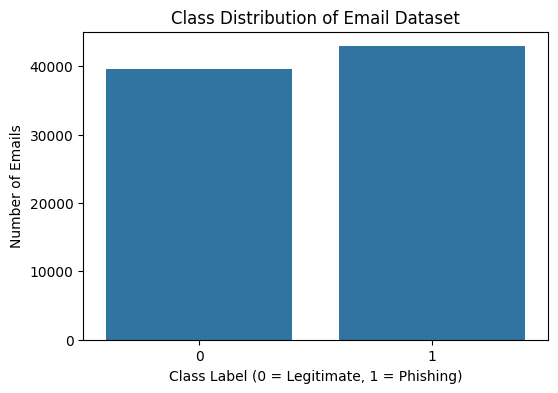

In [127]:
# Visualise class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label")
plt.title("Class Distribution of Email Dataset")
plt.xlabel("Class Label (0 = Legitimate, 1 = Phishing)")
plt.ylabel("Number of Emails")
plt.show()

In [128]:
# Create readable label names for later visualisations
df["label_name"] = df["label"].map({
    0: "Legitimate",
    1: "Phishing"
})

df.head()

,text_combined,label,label_name
0,hpl nom may 25 2001 see attached file hplno 52...,0,Legitimate
1,nom actual vols 24 th forwarded sabrae zajac h...,0,Legitimate
2,enron actuals march 30 april 1 201 estimated a...,0,Legitimate
3,hpl nom may 30 2001 see attached file hplno 53...,0,Legitimate
4,hpl nom june 1 2001 see attached file hplno 60...,0,Legitimate


In [129]:
# Calculate email text length
df["text_length"] = df["text_combined"].astype(str).apply(len)

df["text_length"].describe()

count    8.248600e+04
mean     1.288751e+03
std      1.549675e+04
min      1.000000e+00
25%      2.760000e+02
50%      5.580000e+02
75%      1.338000e+03
max      4.279526e+06
Name: text_length, dtype: float64

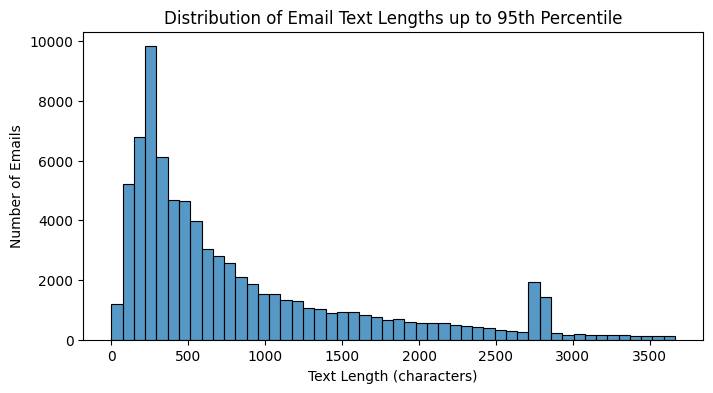

In [130]:
# Visualise text lengths below the 95th percentile to reduce outlier distortion
length_limit = df["text_length"].quantile(0.95)

plt.figure(figsize=(8, 4))
sns.histplot(df[df["text_length"] <= length_limit]["text_length"], bins=50)
plt.title("Distribution of Email Text Lengths up to 95th Percentile")
plt.xlabel("Text Length (characters)")
plt.ylabel("Number of Emails")
plt.show()

In [131]:
def clean_text(text):
    """
    Clean email text for NLP processing.
    This function standardises the text by lowercasing it, removing URLs,
    removing email addresses, removing non-alphabetic characters, and
    normalising whitespace.
    """
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    
    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)
    
    # Remove numbers
    text = re.sub(r"\d+", " ", text)
    
    # Remove non-letter characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [132]:
# Apply text cleaning
df["clean_text"] = df["text_combined"].apply(clean_text)

df[["text_combined", "clean_text", "label"]].head()

,text_combined,clean_text,label
0,hpl nom may 25 2001 see attached file hplno 52...,hpl nom may see attached file hplno xls hplno xls,0
1,nom actual vols 24 th forwarded sabrae zajac h...,nom actual vols th forwarded sabrae zajac hou ...,0
2,enron actuals march 30 april 1 201 estimated a...,enron actuals march april estimated actuals ma...,0
3,hpl nom may 30 2001 see attached file hplno 53...,hpl nom may see attached file hplno xls hplno xls,0
4,hpl nom june 1 2001 see attached file hplno 60...,hpl nom june see attached file hplno xls hplno...,0


In [133]:
# Remove rows where cleaning produced empty text
df = df[df["clean_text"].str.strip() != ""]

print("Shape after cleaning:", df.shape)

Shape after cleaning: (82484, 5)


## Save cleaned version for reproducibility

In [134]:
# Save cleaned version for reproducibility
cleaned_data_path = "../data/phishing_email_cleaned.csv"
df.to_csv(cleaned_data_path, index=False)

print("Cleaned dataset saved to:", cleaned_data_path)

Cleaned dataset saved to: ../data/phishing_email_cleaned.csv


## Train-Test Split and TF-IDF Feature Extraction

In [135]:
# Define features and target variable
X = df["clean_text"]
y = df["label"]

# Split the dataset into training and testing sets
# Stratify keeps the class balance similar in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True) * 100)
print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set size: 65987
Testing set size: 16497

Training class distribution:
label
1    51.996605
0    48.003395
Name: proportion, dtype: float64

Testing class distribution:
label
1    51.997333
0    48.002667
Name: proportion, dtype: float64


In [136]:
# Convert email text into TF-IDF numerical features
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF training matrix shape:", X_train_tfidf.shape)
print("TF-IDF testing matrix shape:", X_test_tfidf.shape)

TF-IDF training matrix shape: (65987, 10000)
TF-IDF testing matrix shape: (16497, 10000)


In [137]:
def evaluate_model(model_name, model, X_test_features, y_test):
    """
    Evaluates a trained classification model using standard metrics.
    Returns a dictionary of results and prints a classification report.
    """
    y_pred = model.predict(X_test_features)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"Model: {model_name}")
    print("-" * 50)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Phishing"]
    ))
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

print("Evaluation function ready.")

Evaluation function ready.


### Baseline Model: Multinomial Naive Bayes

In [138]:
# Train Multinomial Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Evaluate model
nb_results = evaluate_model(
    "Multinomial Naive Bayes",
    nb_model,
    X_test_tfidf,
    y_test
)

Model: Multinomial Naive Bayes
--------------------------------------------------
Accuracy:  0.9594
Precision: 0.9868
Recall:    0.9344
F1-score:  0.9599

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.93      0.99      0.96      7919
    Phishing       0.99      0.93      0.96      8578

    accuracy                           0.96     16497
   macro avg       0.96      0.96      0.96     16497
weighted avg       0.96      0.96      0.96     16497



### Model 2: Logistic Regression

In [139]:
# Train Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

# Evaluate model
lr_results = evaluate_model(
    "Logistic Regression",
    lr_model,
    X_test_tfidf,
    y_test
)

Model: Logistic Regression
--------------------------------------------------
Accuracy:  0.9839
Precision: 0.9833
Recall:    0.9858
F1-score:  0.9845

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.98      0.98      7919
    Phishing       0.98      0.99      0.98      8578

    accuracy                           0.98     16497
   macro avg       0.98      0.98      0.98     16497
weighted avg       0.98      0.98      0.98     16497



### Model 3: Linear Support Vector Machine

In [140]:
# Train Linear SVM model
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_tfidf, y_train)

# Evaluate model
svm_results = evaluate_model(
    "Linear SVM",
    svm_model,
    X_test_tfidf,
    y_test
)

Model: Linear SVM
--------------------------------------------------
Accuracy:  0.9867
Precision: 0.9866
Recall:    0.9879
F1-score:  0.9872

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      7919
    Phishing       0.99      0.99      0.99      8578

    accuracy                           0.99     16497
   macro avg       0.99      0.99      0.99     16497
weighted avg       0.99      0.99      0.99     16497



### Model 4: Random Forest

In [141]:
# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

# Evaluate model
rf_results = evaluate_model(
    "Random Forest",
    rf_model,
    X_test_tfidf,
    y_test
)

Model: Random Forest
--------------------------------------------------
Accuracy:  0.9830
Precision: 0.9862
Recall:    0.9810
F1-score:  0.9836

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.98      7919
    Phishing       0.99      0.98      0.98      8578

    accuracy                           0.98     16497
   macro avg       0.98      0.98      0.98     16497
weighted avg       0.98      0.98      0.98     16497



## Model Comparison

In [142]:
# Combine model results into a dataframe
results_df = pd.DataFrame([
    nb_results,
    lr_results,
    svm_results,
    rf_results
])

# Sort by F1-score
results_df = results_df.sort_values(by="F1-score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1-score
2,Linear SVM,0.986725,0.986611,0.987876,0.987243
1,Logistic Regression,0.983876,0.983256,0.985778,0.984515
3,Random Forest,0.982967,0.986171,0.980998,0.983578
0,Multinomial Naive Bayes,0.959387,0.986826,0.934367,0.959880


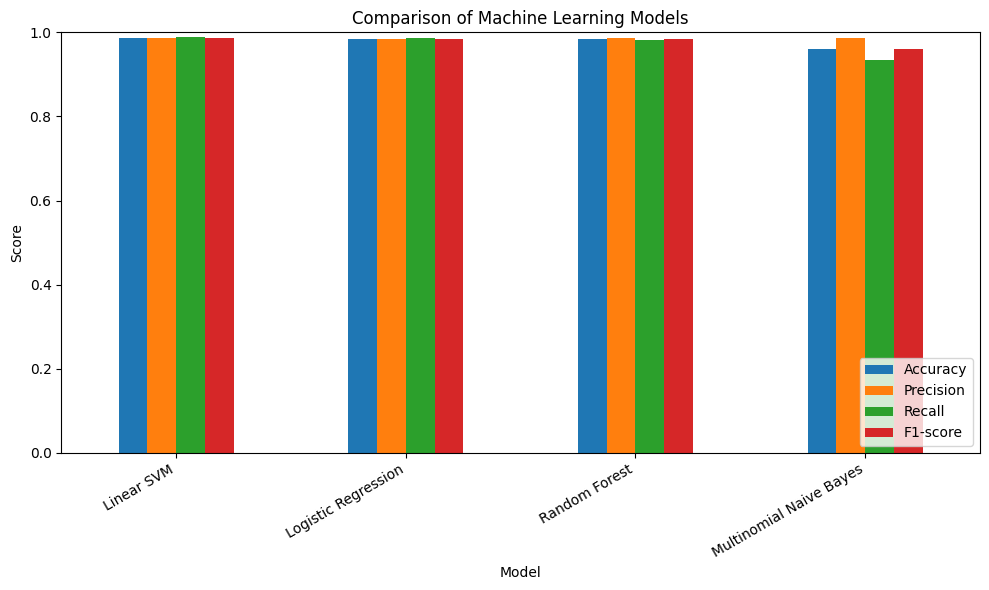

In [143]:
# Visualise model comparison
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Confusion Matrix Analysis

In [144]:
# Function to plot a confusion matrix for a trained model
def plot_confusion_matrix(model, model_name, X_test_features, y_test):
    y_pred = model.predict(X_test_features)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legitimate", "Phishing"]
    )
    
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(values_format="d", ax=ax)
    ax.set_title(f"Confusion Matrix - {model_name}")
    plt.show()
    
    return cm

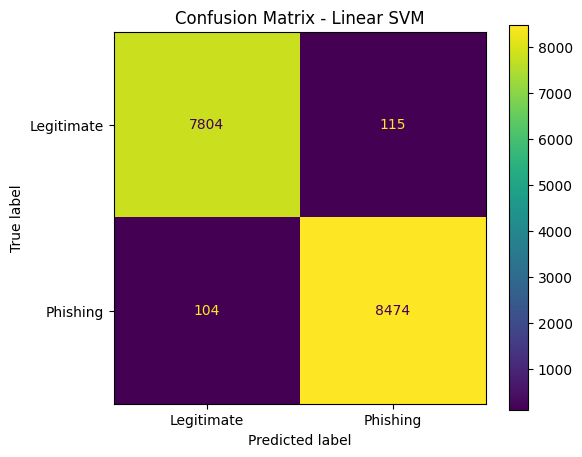

array([[7804,  115],
       [ 104, 8474]])

In [145]:
svm_cm = plot_confusion_matrix(
    svm_model,
    "Linear SVM",
    X_test_tfidf,
    y_test
)

svm_cm

The Linear SVM model produced a strong confusion matrix result. It correctly classified 7,804 legitimate emails and 8,474 phishing emails. There were 115 false positives, where legitimate emails were incorrectly classified as phishing, and 104 false negatives, where phishing emails were incorrectly classified as legitimate. In a phishing detection context, false negatives are particularly important because they represent malicious emails that could potentially reach users without being detected.

In [146]:
# Save model comparison results
results_path = "../results/model_comparison.csv"
results_df.to_csv(results_path, index=False)

print("Model comparison saved to:", results_path)

Model comparison saved to: ../results/model_comparison.csv


In [147]:
# Save the best performing model and TF-IDF vectorizer
model_path = "../models/linear_svm_phishing_model.pkl"
vectorizer_path = "../models/tfidf_vectorizer.pkl"

joblib.dump(svm_model, model_path)
joblib.dump(tfidf_vectorizer, vectorizer_path)

print("Best model saved to:", model_path)
print("TF-IDF vectorizer saved to:", vectorizer_path)

Best model saved to: ../models/linear_svm_phishing_model.pkl
TF-IDF vectorizer saved to: ../models/tfidf_vectorizer.pkl


## Testing the Best Model on Example Emails

In [148]:
# Function to predict whether a new email is phishing or legitimate
def predict_email(email_text):
    cleaned_email = clean_text(email_text)
    email_features = tfidf_vectorizer.transform([cleaned_email])
    prediction = svm_model.predict(email_features)[0]
    
    if prediction == 1:
        return "Phishing"
    else:
        return "Legitimate"

In [149]:
test_email_phishing = """
Dear customer, your account has been suspended due to unusual activity.
Please click the link below to verify your login details immediately.
Failure to do so will result in permanent account closure.
"""

test_email_legitimate = """
Hi team, please find attached the meeting notes from today's project discussion.
Let me know if anything needs updating before Friday.
"""

print("Phishing test email prediction:", predict_email(test_email_phishing))
print("Legitimate test email prediction:", predict_email(test_email_legitimate))

Phishing test email prediction: Phishing
Legitimate test email prediction: Legitimate


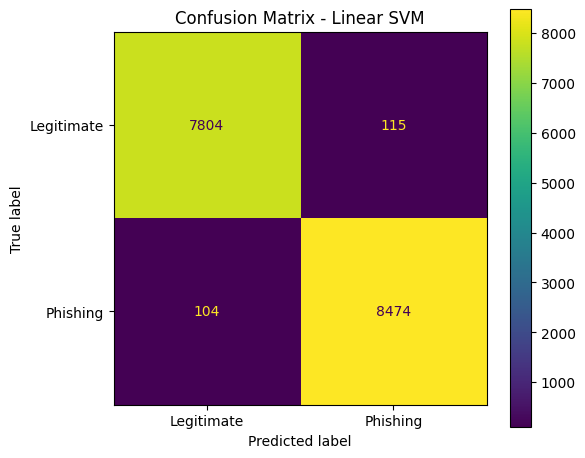

Confusion matrix saved to: ../results/confusion_matrix_linear_svm.png


In [150]:
# Save the Linear SVM confusion matrix figure
y_pred_svm = svm_model.predict(X_test_tfidf)
svm_cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=svm_cm,
    display_labels=["Legitimate", "Phishing"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(values_format="d", ax=ax)
ax.set_title("Confusion Matrix - Linear SVM")
plt.tight_layout()

confusion_matrix_path = "../results/confusion_matrix_linear_svm.png"
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved to:", confusion_matrix_path)